# Movie Recommendation System

# Author : Vaishnavi Waghmare

### Content-Based Filtering
- Uses movie genres to compute similarity.
- Suitable for recommending movies with similar characteristics.
- Does not require user ratings.

### Collaborative Filtering
- Uses user rating behavior.
- Can recommend movies with similar audience preferences.
- Requires sufficient user rating data.

### Comparison

| Method | Advantages | Limitations |
|---------|------------|-------------|
| Content-Based | Fast, no user history required | Limited to movie metadata |
| Collaborative | More personalized | Suffers from cold-start problem |

In [2]:
!pip install scikit-learn pandas numpy matplotlib seaborn

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [4]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

In [5]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [6]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [7]:
movies.info()

ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [8]:
movies.describe()

,movieId
count,9742.000000
mean,42200.353623
std,52160.494854
min,1.000000
25%,3248.250000
50%,7300.000000
75%,76232.000000
max,193609.000000


In [9]:
ratings.describe()

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


In [10]:
movies.isnull().sum()

,0
movieId,0
title,0
genres,0


In [11]:
ratings.isnull().sum()

,0
userId,0
movieId,0
rating,0
timestamp,0


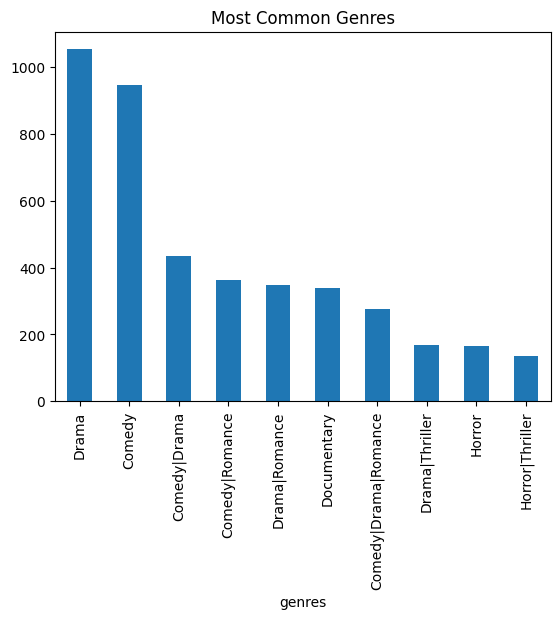

In [12]:
movies['genres'].value_counts().head(10).plot(kind='bar')

plt.title("Most Common Genres")
plt.show()

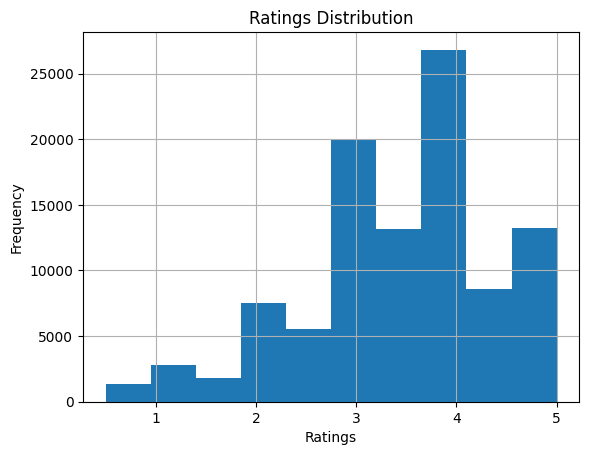

In [13]:
ratings['rating'].hist(bins=10)

plt.xlabel("Ratings")
plt.ylabel("Frequency")
plt.title("Ratings Distribution")

plt.show()

In [14]:
tfidf = TfidfVectorizer(stop_words='english')

movies['genres'] = movies['genres'].fillna('')

tfidf_matrix = tfidf.fit_transform(movies['genres'])

In [15]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [16]:
indices = pd.Series(
    movies.index,
    index=movies['title']
).drop_duplicates()

In [17]:
def recommend_movies(title, cosine_sim=cosine_sim):

    idx = indices[title]

    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )

    sim_scores = sim_scores[1:11]

    movie_indices = [i[0] for i in sim_scores]

    return movies['title'].iloc[movie_indices]

In [18]:
recommend_movies("Toy Story (1995)")

,title
1706,Antz (1998)
2355,Toy Story 2 (1999)
2809,"Adventures of Rocky and Bullwinkle, The (2000)"
3000,"Emperor's New Groove, The (2000)"
3568,"Monsters, Inc. (2001)"
6194,"Wild, The (2006)"
6486,Shrek the Third (2007)
6948,"Tale of Despereaux, The (2008)"
7760,Asterix and the Vikings (Astérix et les Viking...
8219,Turbo (2013)


In [19]:
movie_matrix = ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

In [20]:
movie_matrix = movie_matrix.fillna(0)

In [21]:
movie_similarity = cosine_similarity(movie_matrix.T)

In [22]:
movie_similarity_df = pd.DataFrame(
    movie_similarity,
    index=movie_matrix.columns,
    columns=movie_matrix.columns
)

In [26]:
# Create User-Movie Rating Matrix
movie_matrix = ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

movie_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
movie_matrix = movie_matrix.fillna(0)

movie_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
from sklearn.metrics.pairwise import cosine_similarity

movie_similarity = cosine_similarity(movie_matrix.T)

In [29]:
movie_similarity_df = pd.DataFrame(
    movie_similarity,
    index=movie_matrix.columns,
    columns=movie_matrix.columns
)

movie_similarity_df.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
movieId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.410562,0.296917,0.035573,0.308762,0.376316,0.277491,0.131629,0.232586,0.395573,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.410562,1.000000,0.282438,0.106415,0.287795,0.297009,0.228576,0.172498,0.044835,0.417693,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.296917,0.282438,1.000000,0.092406,0.417802,0.284257,0.402831,0.313434,0.304840,0.242954,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.035573,0.106415,0.092406,1.000000,0.188376,0.089685,0.275035,0.158022,0.000000,0.095598,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.308762,0.287795,0.417802,0.188376,1.000000,0.298969,0.474002,0.283523,0.335058,0.218061,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
def collaborative_recommend(movie_id, top_n=10):
    similar_movies = movie_similarity_df[movie_id]

    similar_movies = similar_movies.sort_values(
        ascending=False
    )

    return similar_movies.iloc[1:top_n+1]

In [31]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [32]:
collaborative_recommend(1)

,1
movieId,
3114,0.572601
480,0.565637
780,0.564262
260,0.557388
356,0.547096
364,0.541145
1210,0.541089
648,0.538913
1265,0.534169


In [33]:
def collaborative_recommend(movie_id, top_n=10):

    similar_movies = movie_similarity_df[movie_id]

    similar_movies = similar_movies.sort_values(
        ascending=False
    )[1:top_n+1]

    recommended = movies[
        movies["movieId"].isin(similar_movies.index)
    ][["movieId", "title", "genres"]]

    return recommended

In [34]:
collaborative_recommend(1)

,movieId,title,genres
224,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
314,356,Forrest Gump (1994),Comedy|Drama|Romance|War
322,364,"Lion King, The (1994)",Adventure|Animation|Children|Drama|Musical|IMAX
418,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
546,648,Mission: Impossible (1996),Action|Adventure|Mystery|Thriller
615,780,Independence Day (a.k.a. ID4) (1996),Action|Adventure|Sci-Fi|Thriller
911,1210,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi
964,1265,Groundhog Day (1993),Comedy|Fantasy|Romance
969,1270,Back to the Future (1985),Adventure|Comedy|Sci-Fi
2355,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy


In [35]:
print("Content-Based Recommendations:")
recommend_movies("Toy Story (1995)")

Content-Based Recommendations:


,title
1706,Antz (1998)
2355,Toy Story 2 (1999)
2809,"Adventures of Rocky and Bullwinkle, The (2000)"
3000,"Emperor's New Groove, The (2000)"
3568,"Monsters, Inc. (2001)"
6194,"Wild, The (2006)"
6486,Shrek the Third (2007)
6948,"Tale of Despereaux, The (2008)"
7760,Asterix and the Vikings (Astérix et les Viking...
8219,Turbo (2013)


In [36]:
print("Collaborative Filtering Recommendations:")
collaborative_recommend(1)

Collaborative Filtering Recommendations:


,movieId,title,genres
224,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
314,356,Forrest Gump (1994),Comedy|Drama|Romance|War
322,364,"Lion King, The (1994)",Adventure|Animation|Children|Drama|Musical|IMAX
418,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
546,648,Mission: Impossible (1996),Action|Adventure|Mystery|Thriller
615,780,Independence Day (a.k.a. ID4) (1996),Action|Adventure|Sci-Fi|Thriller
911,1210,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi
964,1265,Groundhog Day (1993),Comedy|Fantasy|Romance
969,1270,Back to the Future (1985),Adventure|Comedy|Sci-Fi
2355,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy


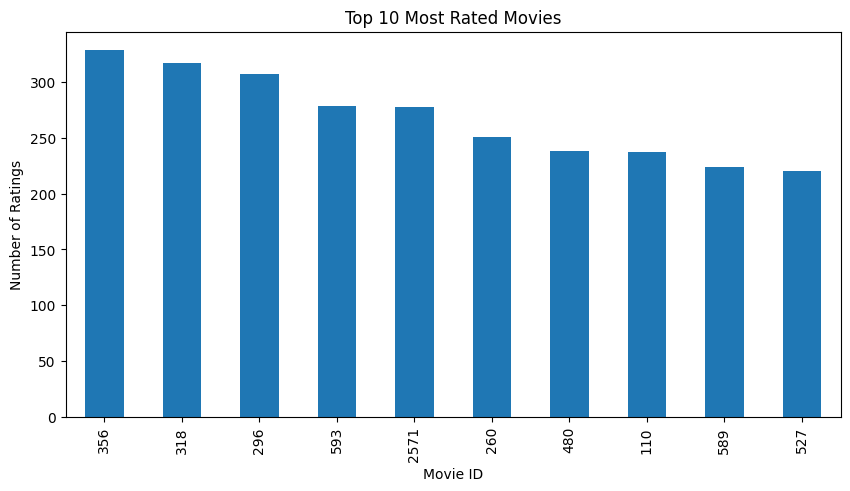

In [37]:
top_movies = ratings["movieId"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_movies.plot(kind="bar")
plt.title("Top 10 Most Rated Movies")
plt.xlabel("Movie ID")
plt.ylabel("Number of Ratings")
plt.show()

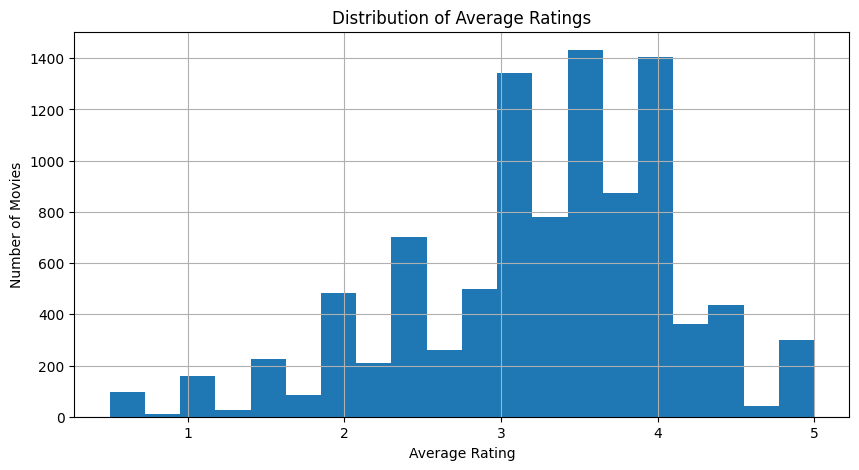

In [38]:
average_rating = ratings.groupby("movieId")["rating"].mean()

plt.figure(figsize=(10,5))
average_rating.hist(bins=20)

plt.title("Distribution of Average Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Number of Movies")
plt.show()

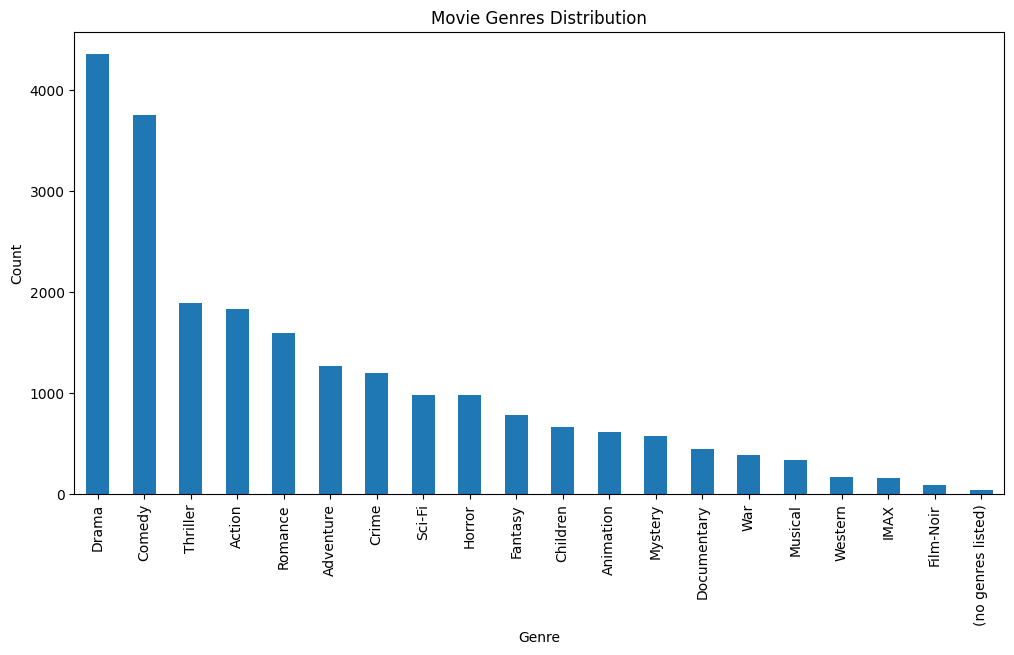

In [39]:
genre_counts = movies["genres"].str.split("|").explode().value_counts()

plt.figure(figsize=(12,6))
genre_counts.plot(kind="bar")

plt.title("Movie Genres Distribution")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

# Conclusion

This project implements two recommendation techniques:

- Content-Based Filtering using TF-IDF and Cosine Similarity
- Collaborative Filtering using User Ratings and Cosine Similarity

The system successfully recommends similar movies based on both movie metadata and user preferences.